# 200 Gbps throughput benchmark

This notebook is a variant of `full_run.ipynb` that replaces the analysis processor with the `TwoHundredGbpsProcessor`. It reads branches and does nothing else, so wall-clock time is dominated by I/O. Use this to measure max throughput on your AF.

The only differences from `full_run.ipynb` are:
- All analysis / skimming / histogramming / statistics flags are off
- The branches config is overridden using `get_branches_for_fraction` (pick a target read fraction)
- `TwoHundredGbpsProcessor` is passed to `run_processor_workflow` instead of `SkimAndAnalyseProcessor`

## Workflow Overview

1. Setup Python path for intccms package
2. Install dependencies and register modules for cloud pickle
3. Acquire Dask client from AF environment
4. Configure parameters (disable all analysis, override branches with throughput helper)
5. Run metadata extraction (`coffea` preprocessing)
6. Run `TwoHundredGbpsProcessor` with coffea.processor.Runner

## AF flag
We might want to run this code on different facilities, which may each have their own limitations or require different dask client setups. To make it easy to switch between facilities, just set the `AF` variable to the one of your choice. If your `AF` does not exist yet, you can introduce it in this notebook in the relevant sections.

In [1]:
AF="coffeacasa-condor" # options currently supported: [coffeacasa-condor, coffeacasa-gateway, purdue-af-k8s, purdue-af-slurm]
AUTO_CLOSE_CLIENT=False # the client setup is done with a contextmanager -- this flag decides if we automatically close the client as we exit the manager. If False, you handle closing manually. 
WARM_XCACHE=False

## Imports and dependencies

### The intccms package
The CMS implementation of the integration challenge is set in a package-like structure, which means we hae to add the source code to the python path. The package is referred to as `intccms`.

In [2]:
# Setup Python path to include intccms package
import sys
from pathlib import Path

# Add src directory to Python path
repo_root = Path.cwd()
src_dir = repo_root / "src"
examples_dir = repo_root
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
if str(examples_dir) not in sys.path:
    sys.path.insert(0, str(examples_dir))
print(f"✅ Added {src_dir} to Python path")
print(f"✅ Added {examples_dir} to Python path")

✅ Added /home/cms-jovyan/intc/integration-challenge/cms/src to Python path
✅ Added /home/cms-jovyan/intc/integration-challenge/cms to Python path


### Installing extra dependencies
The `intccms` package requires `omegaconf` and `roastcoffea`, which is not by default on an AF. `roastcoffea` is a tool developed while working on this project and it provides an API to extract metrics from coffea-processor workflows. 

In [3]:
try:
    import omegaconf
except ImportError:
    print("⚠️ omegaconf not found, installing...")
    ! pip install omegaconf;

try:
    import roastcoffea
except ImportError:
    print("⚠️ roastcoffea not found, installing...")
    ! pip install roastcoffea;

### Alternative coffea version
In some cases, we might need to install our own `coffea` version which is not on the AF. For example, when testing a new feature or using a recently realased version with a fix.

In [4]:
COFFEA_VERSION = "2026.4.0"
COFFEA_PIP = f"coffea=={COFFEA_VERSION}" if "git" not in COFFEA_VERSION else COFFEA_VERSION

! pip install $COFFEA_PIP ;

# Pip-installable dependencies to install on workers
WORKER_DEPENDENCIES = [COFFEA_PIP, "roastcoffea==0.1.2"]

### Imports from stdlib and other libraries

In this notebook we use `dask` and `coffea`. 

In [5]:
# stdlib
import cloudpickle
import copy
import os
import time

from coffea.processor import DaskExecutor, IterativeExecutor
from coffea.nanoevents import NanoAODSchema, BaseSchema

### Imports from intccms and other integration-challenge specific tooling

In [6]:
# intccms
from intccms.schema import Config, load_config_with_restricted_cli
from intccms.utils.output import OutputDirectoryManager
from intccms.metadata_extractor import DatasetMetadataManager
from intccms.datasets import DatasetManager
from intccms.analysis import run_processor_workflow, TwoHundredGbpsProcessor
from intccms.utils.tools import get_branches_for_fraction, warm_xcache

# roastcoffea metrics
from roastcoffea import MetricsCollector

### Registering packages with cloudpickle
The intccms cannot be installed on the workers via `pip`, and the configuration files are in python modules which also cannot be installed on the workers. So we need to register them with `cloudpickle` to allow dask to serialize them and send them out.

In [7]:
import intccms
import example_cms_200gbps

# Register modules for cloud pickle
cloudpickle.register_pickle_by_value(intccms)
cloudpickle.register_pickle_by_value(example_cms_200gbps)

## Dask client setup

This notebook uses the `DaskExecutor` from `coffea` to distribute the task graph on the AF. The client setup varies in different facilities, so we implement a function which returns the correct client. The function does so by providing a context manager, within which the client is alive.

In [8]:
from intccms.utils.dask_client import acquire_client, live_prints

## Configuration Setup

Same configuration loading as `full_run.ipynb`, but with all analysis/skimming/histogramming/statistics turned off. The branches config is overridden with `get_branches_for_fraction` to control what fraction of each file gets read.

In [9]:
# intccms configuration import
from example_cms_200gbps.configs.configuration import config as original_config

# Create a deepcopy that we can manipulate
config = copy.deepcopy(original_config)

# Limit files for testing
config["datasets"]["max_files"] = None # None would run over all availale files

# Skip known-bad files
config["datasets"]["skip_files"] = [
    "92D0BDF3-91AE-514F-88B5-8F591450B8AD.root",
    "8E2613E5-9327-D644-9567-C3A5CE721D27.root"
]

# Use local output directory
config["general"]["output_dir"] = "example_cms_200gbps/outputs/"

# Preprocessing (coffea) can be executed once and results loaded
config["general"]["run_metadata_generation"] = True

# Processor: only read branches, no analysis or skimming
config["general"]["run_processor"] = True
config["general"]["run_analysis"] = False
config["general"]["save_skimmed_output"] = False
config["general"]["run_histogramming"] = False
config["general"]["run_systematics"] = False
config["general"]["run_corrections"] = False
config["general"]["run_statistics"] = False

# ---------------------------------------------------------------------------
# Override branches: pick the biggest branches covering TARGET_FRACTION of
# the file. Set cache_path so subsequent runs skip the slow measurement step.
#
# If you have a representative data file, pass data_file= to split MC-only
# branches into mc_branches automatically.
# ---------------------------------------------------------------------------
TARGET_FRACTION = 0.04  # fraction of file to read (1.0 = everything)

SAMPLE_MC_FILE = (
    "root://xcache//store/mc/RunIISummer20UL16NanoAODv9/ZPrimeToTT_M2000_W200_TuneCP2_13TeV-madgraph-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/2530000/288B512F-09A1-5D48-8D1B-6216C5904FB5.root"
)
SAMPLE_DATA_FILE = (
    "root://xcache//store/data/Run2016C/SingleMuon/NANOAOD/HIPM_UL2016_MiniAODv2_NanoAODv9-v2/40000/1D381615-0139-A540-AC3C-B3BC7C2B781F.root"
)
BRANCH_CACHE = "example_cms/configs/branch_sizes.json"

branches, mc_branches = get_branches_for_fraction(
    SAMPLE_MC_FILE,
    target_fraction=TARGET_FRACTION,
    cache_path=BRANCH_CACHE,
    data_file=SAMPLE_DATA_FILE,
    veto=("LHEPdfWeight","GenPart", "GenJet", "TrigObj", "LHEPart"),
)
config["preprocess"]["branches"] = branches
config["preprocess"]["mc_branches"] = mc_branches

print(f"Branches: {sum(len(v) for v in branches.values())} fields across {len(branches)} collections")
print(f"MC-only branches: {sum(len(v) for v in mc_branches.values())} fields")

print(branches, "\n", mc_branches)

cli_args = []
full_config = load_config_with_restricted_cli(config, cli_args)
validated_config = Config(**full_config)

Branches: 8 fields across 1 collections
MC-only branches: 0 fields
{'Jet': ['eta', 'phi', 'btagDeepFlavB', 'pt', 'mass', 'btagDeepFlavCvL', 'btagDeepFlavCvB', 'btagDeepB']} 
 {}


## Running the Workflow

Same steps as `full_run.ipynb`:

1. Setting up output directories
2. Building an input dataset manager
3. Running or loading the coffea preprocessing
4. Run the throughput processor (instead of the analysis processor)

### Output manager setup

In [21]:
output_manager = OutputDirectoryManager(
    root_output_dir=validated_config.general.output_dir,
    cache_dir=validated_config.general.cache_dir,
    metadata_dir=validated_config.general.metadata_dir,
    skimmed_dir=validated_config.general.skimmed_dir
)

lumi=16400.0 weight_branch='genWeight' analysis='cms' use_skimmed_input=False save_skimmed_output=False run_processor=True run_analysis=False run_histogramming=False run_statistics=False run_systematics=False run_corrections=False run_plots_only=False run_mva_training=False run_metadata_generation=True read_from_cache=True output_dir='example_cms/outputs/' cache_dir='/tmp/integration/' metadata_dir=None skimmed_dir=None processes=None channels=None metrics=MetricsConfig(enable=True, track_workers=True, worker_tracking_interval=1.0, save_measurements=True, generate_plots=True, generate_reports=True, measurement_name=None, target_throughput_gbps=200.0)


15:13:55 INFO     Output directory manager initialized with root:                                ]8;id=676874;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/output/directories.py\directories.py]8;;\:]8;id=48507;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/output/directories.py#169\169]8;;\
                  /home/cms-jovyan/intc/integration-challenge/cms/example_cms/outputs                              

### Configure Data Redirector (Optional)

Override the redirector in the config for accessing dataset files. Useful for testing different storage backends. You can also change this in `example_cms/configs/skim.py`

In [11]:
# Override redirector for all datasets
# Examples:
#   "root://xcache/"                    
#   "root://cmsxrootd.fnal.gov/"
#   "root://cms-xrd-global.cern.ch/"
REDIRECTOR = "root://xcache/"  # Change this to use a different redirector

print(f"Initial redirector  {validated_config.datasets.datasets[0].name}: {validated_config.datasets.datasets[0].redirector}")

# Apply to all datasets in config
for dataset in validated_config.datasets.datasets:
 dataset.redirector = REDIRECTOR

print(f"Redirector set to: {REDIRECTOR}")

# Verify the change
print(f"New redirector:  {validated_config.datasets.datasets[0].name}: {validated_config.datasets.datasets[0].redirector}")

Initial redirector  signal: root://xcache/
Redirector set to: root://xcache/
New redirector:  signal: root://xcache/


### Input dataset manager setup

In [12]:
dataset_manager = DatasetManager(validated_config.datasets)

         INFO     Initialized dataset manager with 10 datasets                                        ]8;id=394305;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/datasets/manager.py\manager.py]8;;\:]8;id=703948;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/datasets/manager.py#34\34]8;;\

### Warm xcache

Read all files once through xcache so they're cached before the benchmark.

In [13]:
if WARM_XCACHE:
    with acquire_client(AF, close_after=AUTO_CLOSE_CLIENT, pip_packages=WORKER_DEPENDENCIES) as (client, cluster):
        results, meta = warm_xcache(dataset_manager, client)

    print(f"Files: {meta['n_files']}")
    print(f"Total: {meta['total_GB']:.1f} GB in {meta['wall_time_s']:.1f}s")
    print(f"Throughput: {meta['total_Gbps']:.2f} Gbps (wall clock), {meta['per_worker_Gbps']:.2f} Gbps (per worker)")

### Coffea preprocessing

In [14]:
metadata_generator = DatasetMetadataManager(
  dataset_manager=dataset_manager,
  output_manager=output_manager,
  config=validated_config,
)

if metadata_generator.generate_metadata:
  with acquire_client(AF, close_after=AUTO_CLOSE_CLIENT, pip_packages=WORKER_DEPENDENCIES) as (client, cluster):
      metadata_generator.run(executor=DaskExecutor(client=client))
else:
  metadata_generator.run()  # No client needed

# Build metadata lookup and extract workitems
metadata_lookup = metadata_generator.build_metadata_lookup()
workitems = metadata_generator.workitems
;

         INFO     Initialized DatasetMetadataManager with output dir:                                ]8;id=608195;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py\manager.py]8;;\:]8;id=90316;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py#131\131]8;;\
                  /home/cms-jovyan/intc/integration-challenge/cms/example_cms/outputs/metadata                     

13:52:34 INFO     Connected to Dask scheduler                                                    ]8;id=44182;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py\dask_client.py]8;;\:]8;id=86116;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py#247\247]8;;\

         INFO     Dashboard: /user/mohamed.aly@cern.ch/proxy/8787/status                         ]8;id=795929;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py\dask_client.py]8;;\:]8;id=520188;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py#248\248]8;;\

         INFO     Starting metadata generation workflow...                                           ]8;id=364679;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py\manager.py]8;;\:]8;id=731524;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py#206\206]8;;\

         INFO     Building fileset for process: signal                                              ]8;id=246090;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/builders.py\builders.py]8;;\:]8;id=493741;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/builders.py#124\124]8;;\

...

         INFO     Saved JSON to                                                                           ]8;id=655613;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/io.py\io.py]8;;\:]8;id=51718;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/io.py#115\115]8;;\
                  /home/cms-jovyan/intc/integration-challenge/cms/example_cms/outputs/metadata/nanoaods_d          
                  ata_12_nominal.json                                                                              

         INFO     Saved JSON to                                                                           ]8;id=974955;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/io.py\io.py]8;;\:]8;id=849331;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/io.py#115\115]8;;\
                  /home/cms-jovyan/intc/integration-challenge/cms/example_cms/outputs/metadata/nanoaods_d          
                  ata_13_nominal.json                                                                              

         INFO     Metadata generation complete.                                                      ]8;id=263297;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py\manager.py]8;;\:]8;id=677080;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py#227\227]8;;\

         INFO     Built metadata lookup for 125 fileset keys                                         ]8;id=133221;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py\manager.py]8;;\:]8;id=520066;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/metadata_extractor/manager.py#460\460]8;;\

''

### Run Throughput Processor

In [15]:
# Create the throughput processor
processor = TwoHundredGbpsProcessor(
    config=validated_config,
    output_manager=output_manager,
    metadata_lookup=metadata_lookup,
)

# Run processor workflow with roastcoffea metrics collection
with acquire_client(AF, close_after=AUTO_CLOSE_CLIENT, pip_packages=WORKER_DEPENDENCIES, profile_output_dir=f"{output_manager.root_output_dir}/profiling/", profile_suffix="200gbps_preload",) as (client, cluster):
    with MetricsCollector(
        client=client,
        processor_instance=processor,
        track_workers=True,
        worker_tracking_interval=1.0,
    ) as collector:
        t0 = time.perf_counter()
        output, report = run_processor_workflow(
            config=validated_config,
            output_manager=output_manager,
            metadata_lookup=metadata_lookup,
            processor=processor,
            workitems=workitems,
            executor=DaskExecutor(client=client, treereduction=8, retries=0),
            schema=BaseSchema,
            preload=True,
        )
        t1 = time.perf_counter()

        # Extract chunk metrics injected by @track_metrics decorator
        collector.extract_metrics_from_output(output)
        collector.set_coffea_report(report)

    # Get aggregated metrics after context exits
    metrics = collector.get_metrics()
    tracking_data = collector.tracking_data
    span_metrics = getattr(collector, "span_metrics", None)

wall_time = t1 - t0
print(f"Done in {wall_time:.1f} seconds")
print(f"Total events processed: {output.get('processed_events', 0):,}")

         INFO     Initialized TwoHundredGbpsProcessor: 8 branches to materialize                  ]8;id=597097;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/processors.py\processors.py]8;;\:]8;id=383787;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/processors.py#536\536]8;;\

13:53:14 INFO     Connected to Dask scheduler                                                    ]8;id=618784;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py\dask_client.py]8;;\:]8;id=286074;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py#247\247]8;;\

         INFO     Dashboard: /user/mohamed.aly@cern.ch/proxy/8787/status                         ]8;id=187882;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py\dask_client.py]8;;\:]8;id=104210;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py#248\248]8;;\

         INFO     Running processor over data...                                                      ]8;id=265380;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py\runner.py]8;;\:]8;id=96563;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py#122\122]8;;\

         INFO     Processing 39591 work items with chunksize=200000                                   ]8;id=507049;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py\runner.py]8;;\:]8;id=790703;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py#222\222]8;;\

...

Output()

14:02:23 INFO     TwoHundredGbpsProcessor done: 6,827,277,103 events read                         ]8;id=298221;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/processors.py\processors.py]8;;\:]8;id=413345;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/processors.py#583\583]8;;\

         INFO     Processor complete: 6,827,277,103 events processed, 0 events after skim             ]8;id=847277;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py\runner.py]8;;\:]8;id=234160;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/analysis/runner.py#229\229]8;;\

14:02:36 INFO     Saved Dask profile to                                                          ]8;id=480468;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py\dask_client.py]8;;\:]8;id=214962;file:///home/cms-jovyan/intc/integration-challenge/cms/src/intccms/utils/dask_client.py#260\260]8;;\
                  /home/cms-jovyan/intc/integration-challenge/cms/example_cms/outputs/profiling/                   
                  20260416_140226/dask_profile_200gbps_preload.html                                                

Done in 549.6 seconds
Total events processed: 6,827,277,103


## Performance Metrics (roastcoffea)

Summary tables and visualizations from the metrics collected during the throughput benchmark.

### Summary Tables

In [16]:
# from rich.console import Console
# from roastcoffea.export.reporter import (
#     format_throughput_table,
#     format_event_processing_table,
#     format_resources_table,
#     format_timing_table,
#     format_fine_metrics_table,
#     format_chunk_metrics_table,
# )

# console = Console()

# print("Throughput Metrics")
# console.print(format_throughput_table(metrics))

# print("\nEvent Processing Metrics")
# console.print(format_event_processing_table(metrics))

# print("\nResource Utilization")
# console.print(format_resources_table(metrics))

# print("\nTiming Breakdown")
# console.print(format_timing_table(metrics))

# print("\nChunk Metrics (timing + memory per section)")
# chunk_table = format_chunk_metrics_table(metrics)
# if chunk_table:
#     console.print(chunk_table)
# else:
#     print("No chunk metrics available")

# print("\nFine-Grained Metrics (CPU/IO Breakdown)")
# console.print(format_fine_metrics_table(metrics))

### Timeline Plots

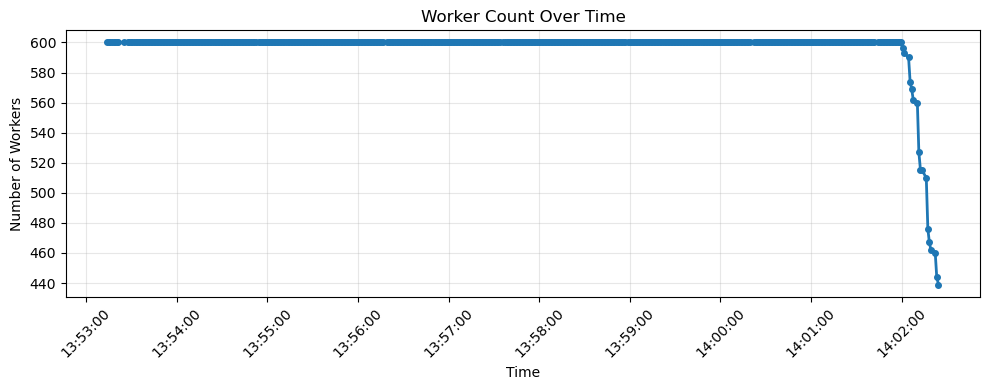

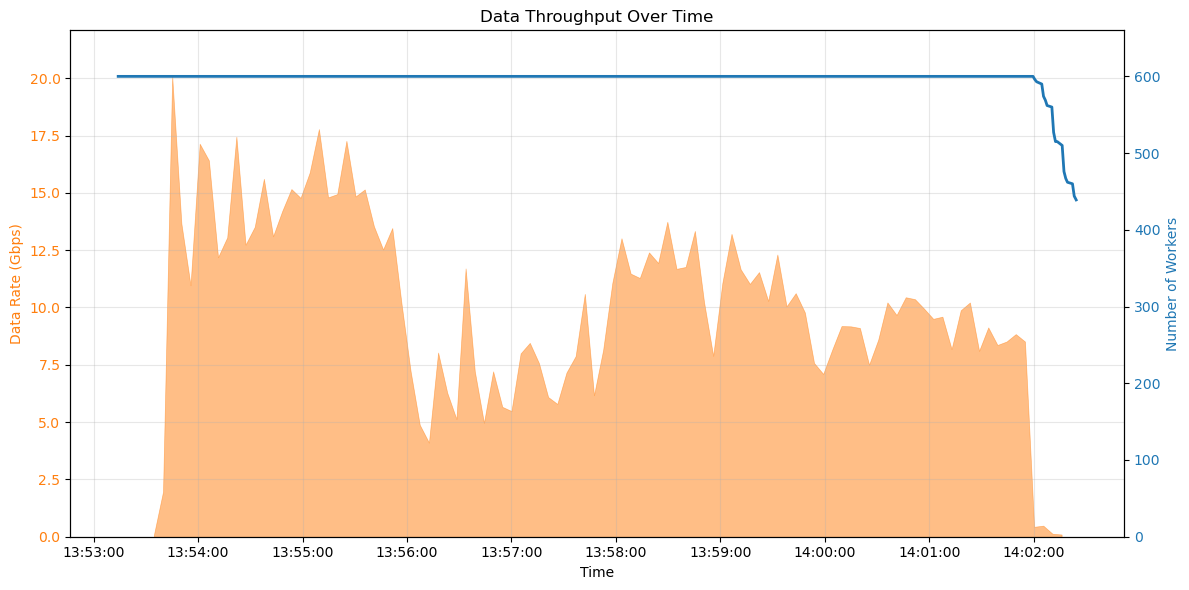

In [17]:
import matplotlib.pyplot as plt
from roastcoffea.visualization.plots import (
    plot_worker_count_timeline,
    plot_memory_utilization_mean_timeline,
    plot_memory_utilization_per_worker_timeline,
    plot_cpu_utilization_mean_timeline,
    plot_cpu_utilization_per_worker_timeline,
    plot_throughput_timeline,
    plot_per_task_cpu_io,
    plot_runtime_distribution,
    plot_runtime_vs_events,
)

# Worker count over time
fig, ax = plot_worker_count_timeline(tracking_data)
plt.show()

# Data throughput over time
fig, ax = plot_throughput_timeline(metrics["chunk_info"], tracking_data)
plt.show()

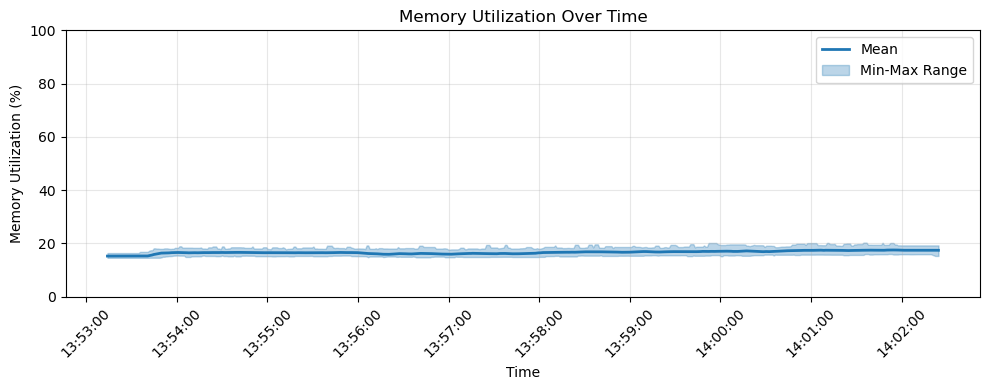

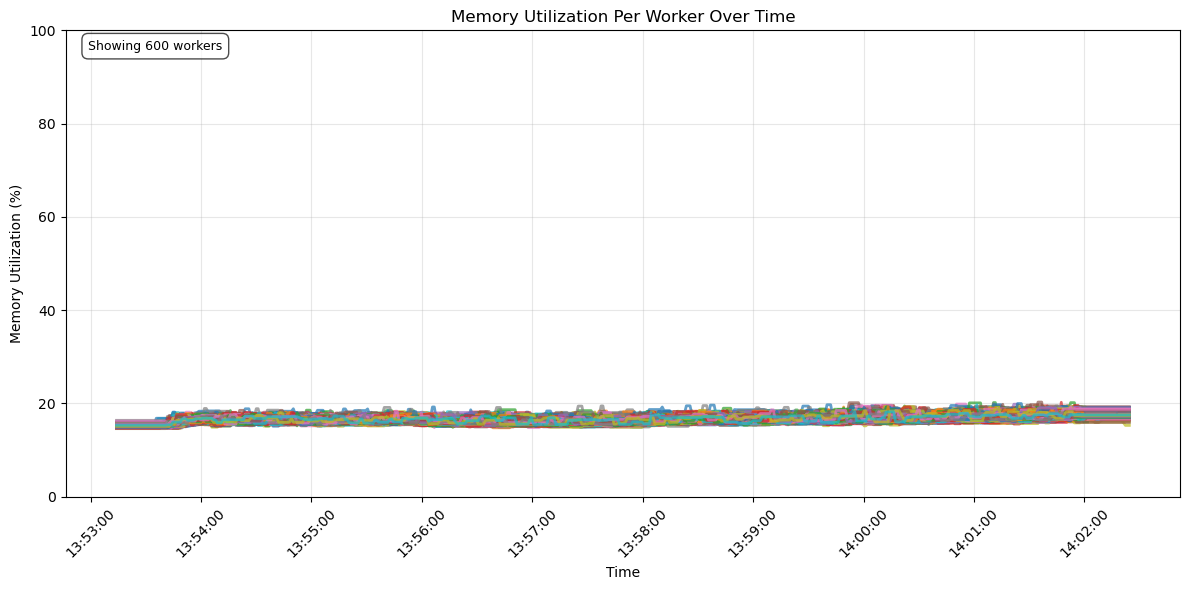

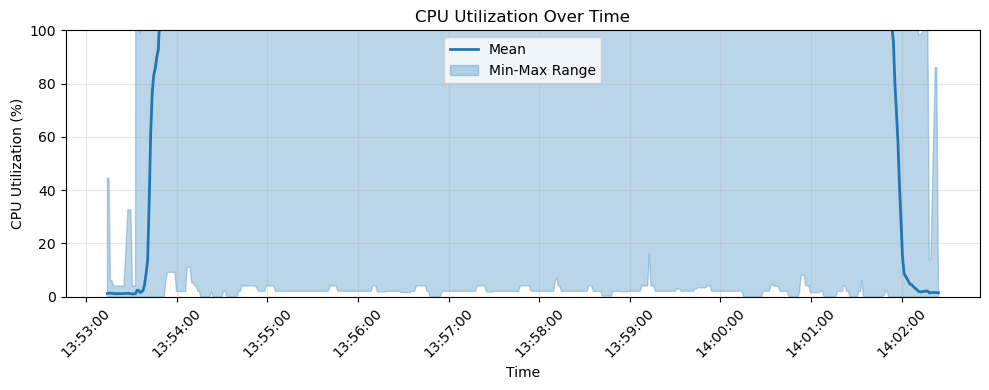

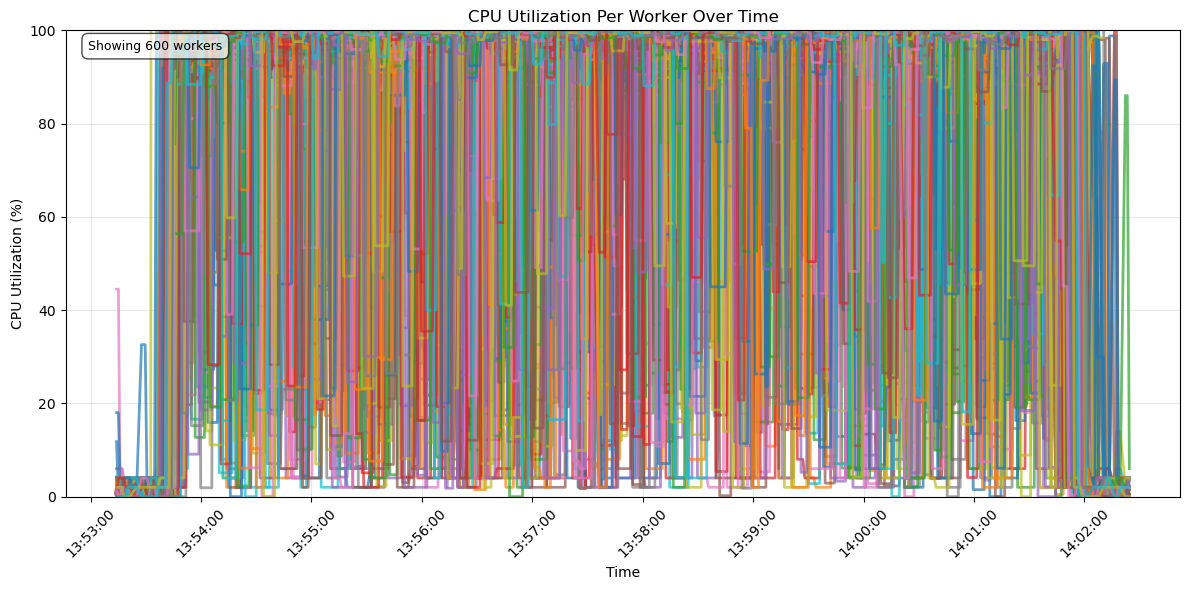

In [18]:
# Memory utilization (mean across workers, then per-worker)
fig, ax = plot_memory_utilization_mean_timeline(tracking_data)
plt.show()

fig, ax = plot_memory_utilization_per_worker_timeline(tracking_data)
plt.show()

# CPU utilization (mean across workers, then per-worker)
fig, ax = plot_cpu_utilization_mean_timeline(tracking_data)
plt.show()

fig, ax = plot_cpu_utilization_per_worker_timeline(tracking_data)
plt.show()

### Task and Processor Breakdown

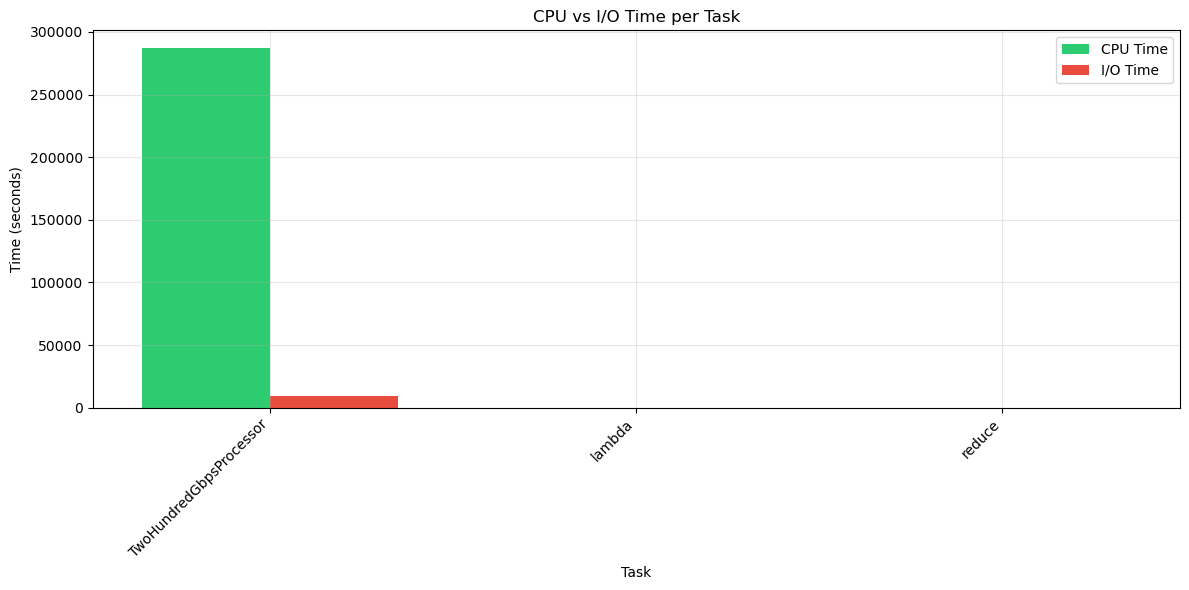

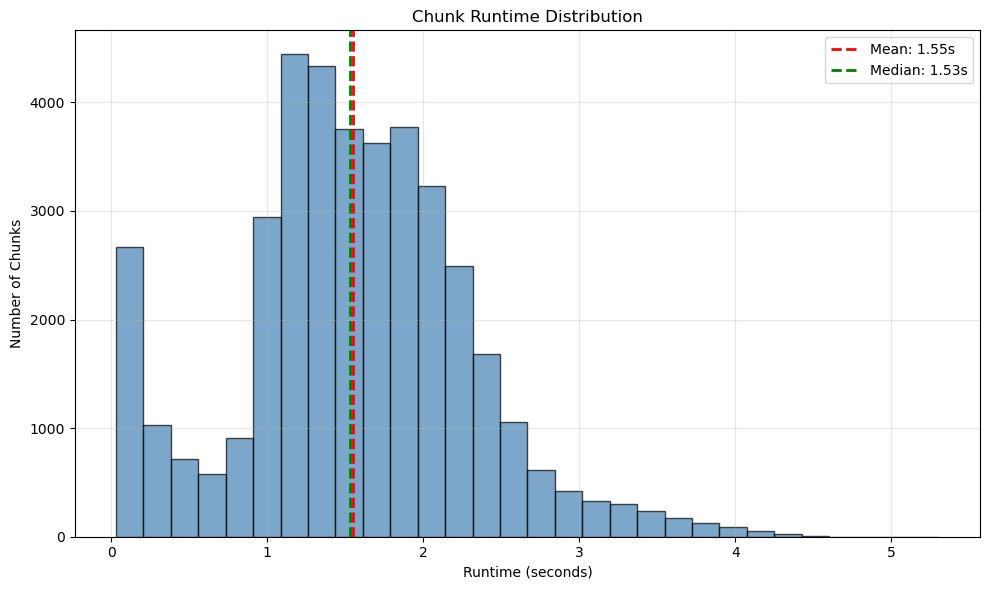

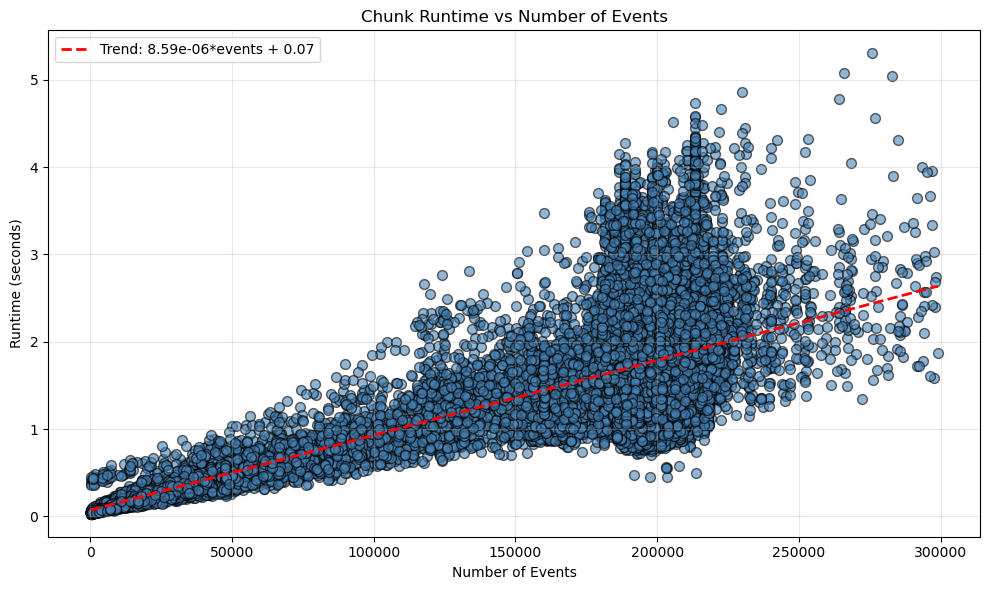

In [19]:
# CPU vs non-CPU time per task (from Dask Spans)
if span_metrics:
    fig, ax = plot_per_task_cpu_io(span_metrics)
    plt.show()
else:
    print("Span metrics not available")

# Chunk runtime distribution
fig, ax = plot_runtime_distribution(metrics.get("raw_chunk_metrics"))
plt.show()

# Runtime vs number of events (scaling behavior)
fig, ax = plot_runtime_vs_events(metrics.get("raw_chunk_metrics"))
plt.show()